In [3]:
import numpy as np
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath('..'))
import matplotlib.pyplot as plt
from scripts import nodes as n
from scripts import elements as e
from scripts import material_params as mat
from scipy.linalg import eigh
import plotly.graph_objects as go

In [5]:
nodes = []
nodal_vals = np.loadtxt('../text_files/retaining_wall_nodes.txt')
for i in range(nodal_vals.shape[0]):
  nodes.append(n.nodes(nodal_vals[i, 2], nodal_vals[i, 3], nodal_vals[i, 4]))

In [6]:
E = 210e9 #Pa
k = 5/6
rho = 7850 #kg/m^3
nu = 0.3 #Poisson's ratio
G = E/(2*(1+nu)) #Pa
t_eff = 1#m
A_eq_wall, I_eqy_wall, I_eqz_wall, b_eq_wall, rho_wall = mat.effective_retaining_wall_stiffness(t_eff)
Ip_wall = I_eqy_wall + I_eqz_wall
It_wall = (b_eq_wall * t_eff**3 / 3) * (1 - 0.63 * (b_eq_wall / t_eff) + 0.052 * (b_eq_wall / t_eff) **5)
ep_K_wall = [E, G, A_eq_wall, I_eqy_wall, I_eqz_wall, It_wall, k]
ep_m_wall = [rho_wall, A_eq_wall, I_eqy_wall, I_eqz_wall, Ip_wall]
k_fender = mat.stiffness_fenders()



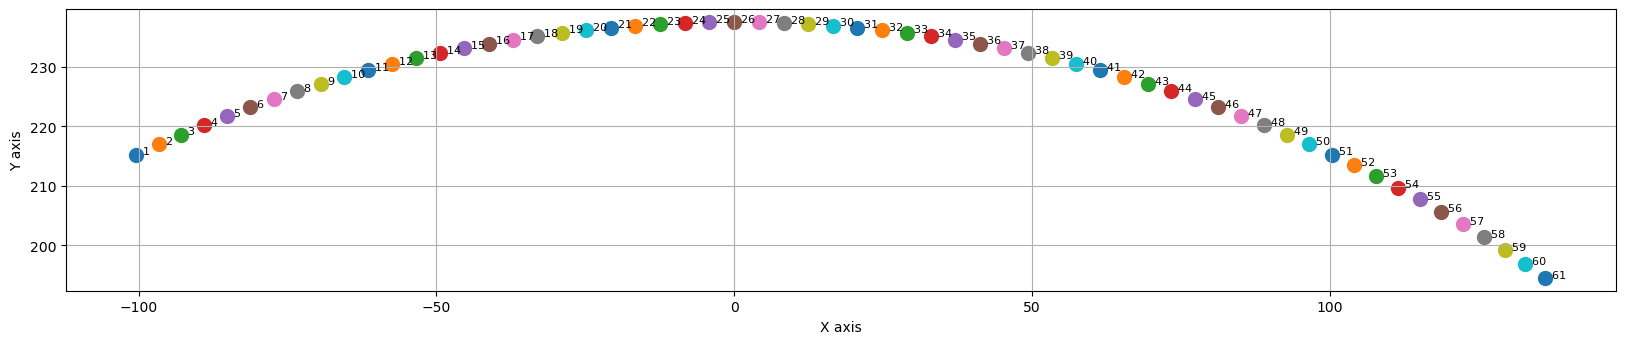

In [7]:
n.plot_nodes2d(nodes)

In [10]:
elements = []
element_vals = np.loadtxt('../text_files/retaining_wall_elements.txt', dtype=int)


for i in range(len(element_vals)):
    elements.append(e.elements(nodes[element_vals[i, 0] - 1], nodes[element_vals[i, 1] - 1], ep_K_wall, ep_m_wall))

dofs = n.degrees_of_freedom(nodes)

element_locs = []

for (nA, nB) in element_vals:
    dofs_A = dofs[f'dof_{nA}']
    dofs_B = dofs[f'dof_{nB}']
    element_locs.append(np.hstack((dofs_A, dofs_B)))

In [11]:
N = len(nodes)
DOFS_per_node = 6



K_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))
M_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))

K_locs = []
M_locs = []



for i in range(len(element_locs)):
    K_global[np.ix_(element_locs[i], element_locs[i])] += elements[i][-1]
    M_global[np.ix_(element_locs[i], element_locs[i])] += elements[i][-2]



# To restore symmetry of the global stiffness and mass matrices
K_global = 0.5 * (K_global + K_global.T)
M_global = 0.5 * (M_global + M_global.T)


fender_dofs = [0, 5, 9, 13, 17, 21, 25, 29, 33, 37, 41, 45, 49, 53, 58]

k_fender_dofs = [dofs[f'dof_{i+1}'][2] for i in fender_dofs]
for dof in k_fender_dofs:
    K_global[dof, dof] += k_fender


In [12]:
indices_to_remove = np.hstack((dofs['dof_61'][0:2]))
keep_indices = np.setdiff1d(np.arange(N * DOFS_per_node), indices_to_remove)
K_global_reduced = K_global[np.ix_(keep_indices, keep_indices)]
M_global_reduced = M_global[np.ix_(keep_indices, keep_indices)]

In [13]:
eigvals_global, eigvecs_global = eigh(K_global_reduced, M_global_reduced)


tol = 1e-6
positive = eigvals_global > tol
eigvals_global = eigvals_global[positive]
eigvecs_global = eigvecs_global[:, positive]

frequencies_rad = np.sqrt(eigvals_global)
frequencies_hz = frequencies_rad / (2 * np.pi)


data_freqs = pd.DataFrame({
    'Frequency (Hz)': frequencies_hz,
    'Frequency (rad/s)': frequencies_rad
})

display(data_freqs[:15])


,Frequency (Hz),Frequency (rad/s)
0,2.515308,15.804146
1,2.852897,17.925282
2,3.299065,20.728639
3,4.722138,29.670066
4,5.477062,34.413398
5,6.433664,40.423903
6,6.744154,42.374770
7,8.081393,50.776892
8,8.299587,52.147843
9,8.808665,55.346472


In [14]:
eigvecs_full = e.expand_eigenvectors(eigvecs_global, keep_indices, N*DOFS_per_node)
print("Expanded eigenvectors shape:", eigvecs_full.shape)

Expanded eigenvectors shape: (366, 363)


In [15]:
eigvecs_disp_full = e.extract_displacement(eigvecs_full, keep=3, skip=3)
eigvecs_full.shape


(366, 363)

In [16]:
modes_to_plot = 7
modes = []
for i in range(modes_to_plot):
    modes.append(eigvecs_disp_full[:, i].reshape(-1, 3))

In [17]:

# for i in range(modes_to_plot):
#     line_x = []
#     line_y = []
#     line_z = []
#     for nA, nB in element_vals:
#         p1 = modes[i][nA - 1]
#         p2 = modes[i][nB - 1]
#         line_x.extend([p1[0], p2[0], None])
#         line_y.extend([p1[1], p2[1], None])
#         line_z.extend([p1[2], p2[2], None])

#     fig_lines = go.Figure(
#         data=[
#             go.Scatter3d(
#                 x=line_x,
#                 y=line_y,
#                 z=line_z,
#                 mode='lines',
#                 line=dict(color='black', width=2)
#             ),
#             go.Scatter3d(
#                 x=modes[i][:, 0],
#                 y=modes[i][:, 1],
#                 z=modes[i][:, 2],
#                 mode='markers',
#                 marker=dict(size=3, color='blue')
#             )
#         ]
#     )

#     # X = modes[i][:, 0]
#     # Y = modes[i][:, 1]
#     # Z = modes[i][:, 2]
#     # e.set_equal_aspect(fig_lines, X, Y, Z)

#     fig_lines.update_layout(
#         title=f'Mode {i+1} - Deformed Configuration (Elements)',
#         scene=dict(
#             xaxis_title='X (m)',
#             yaxis_title='Y (m)',
#             zaxis_title='Z (m)'
#         ),
#         width=900,
#         height=700
#     )

#     fig_lines.show()

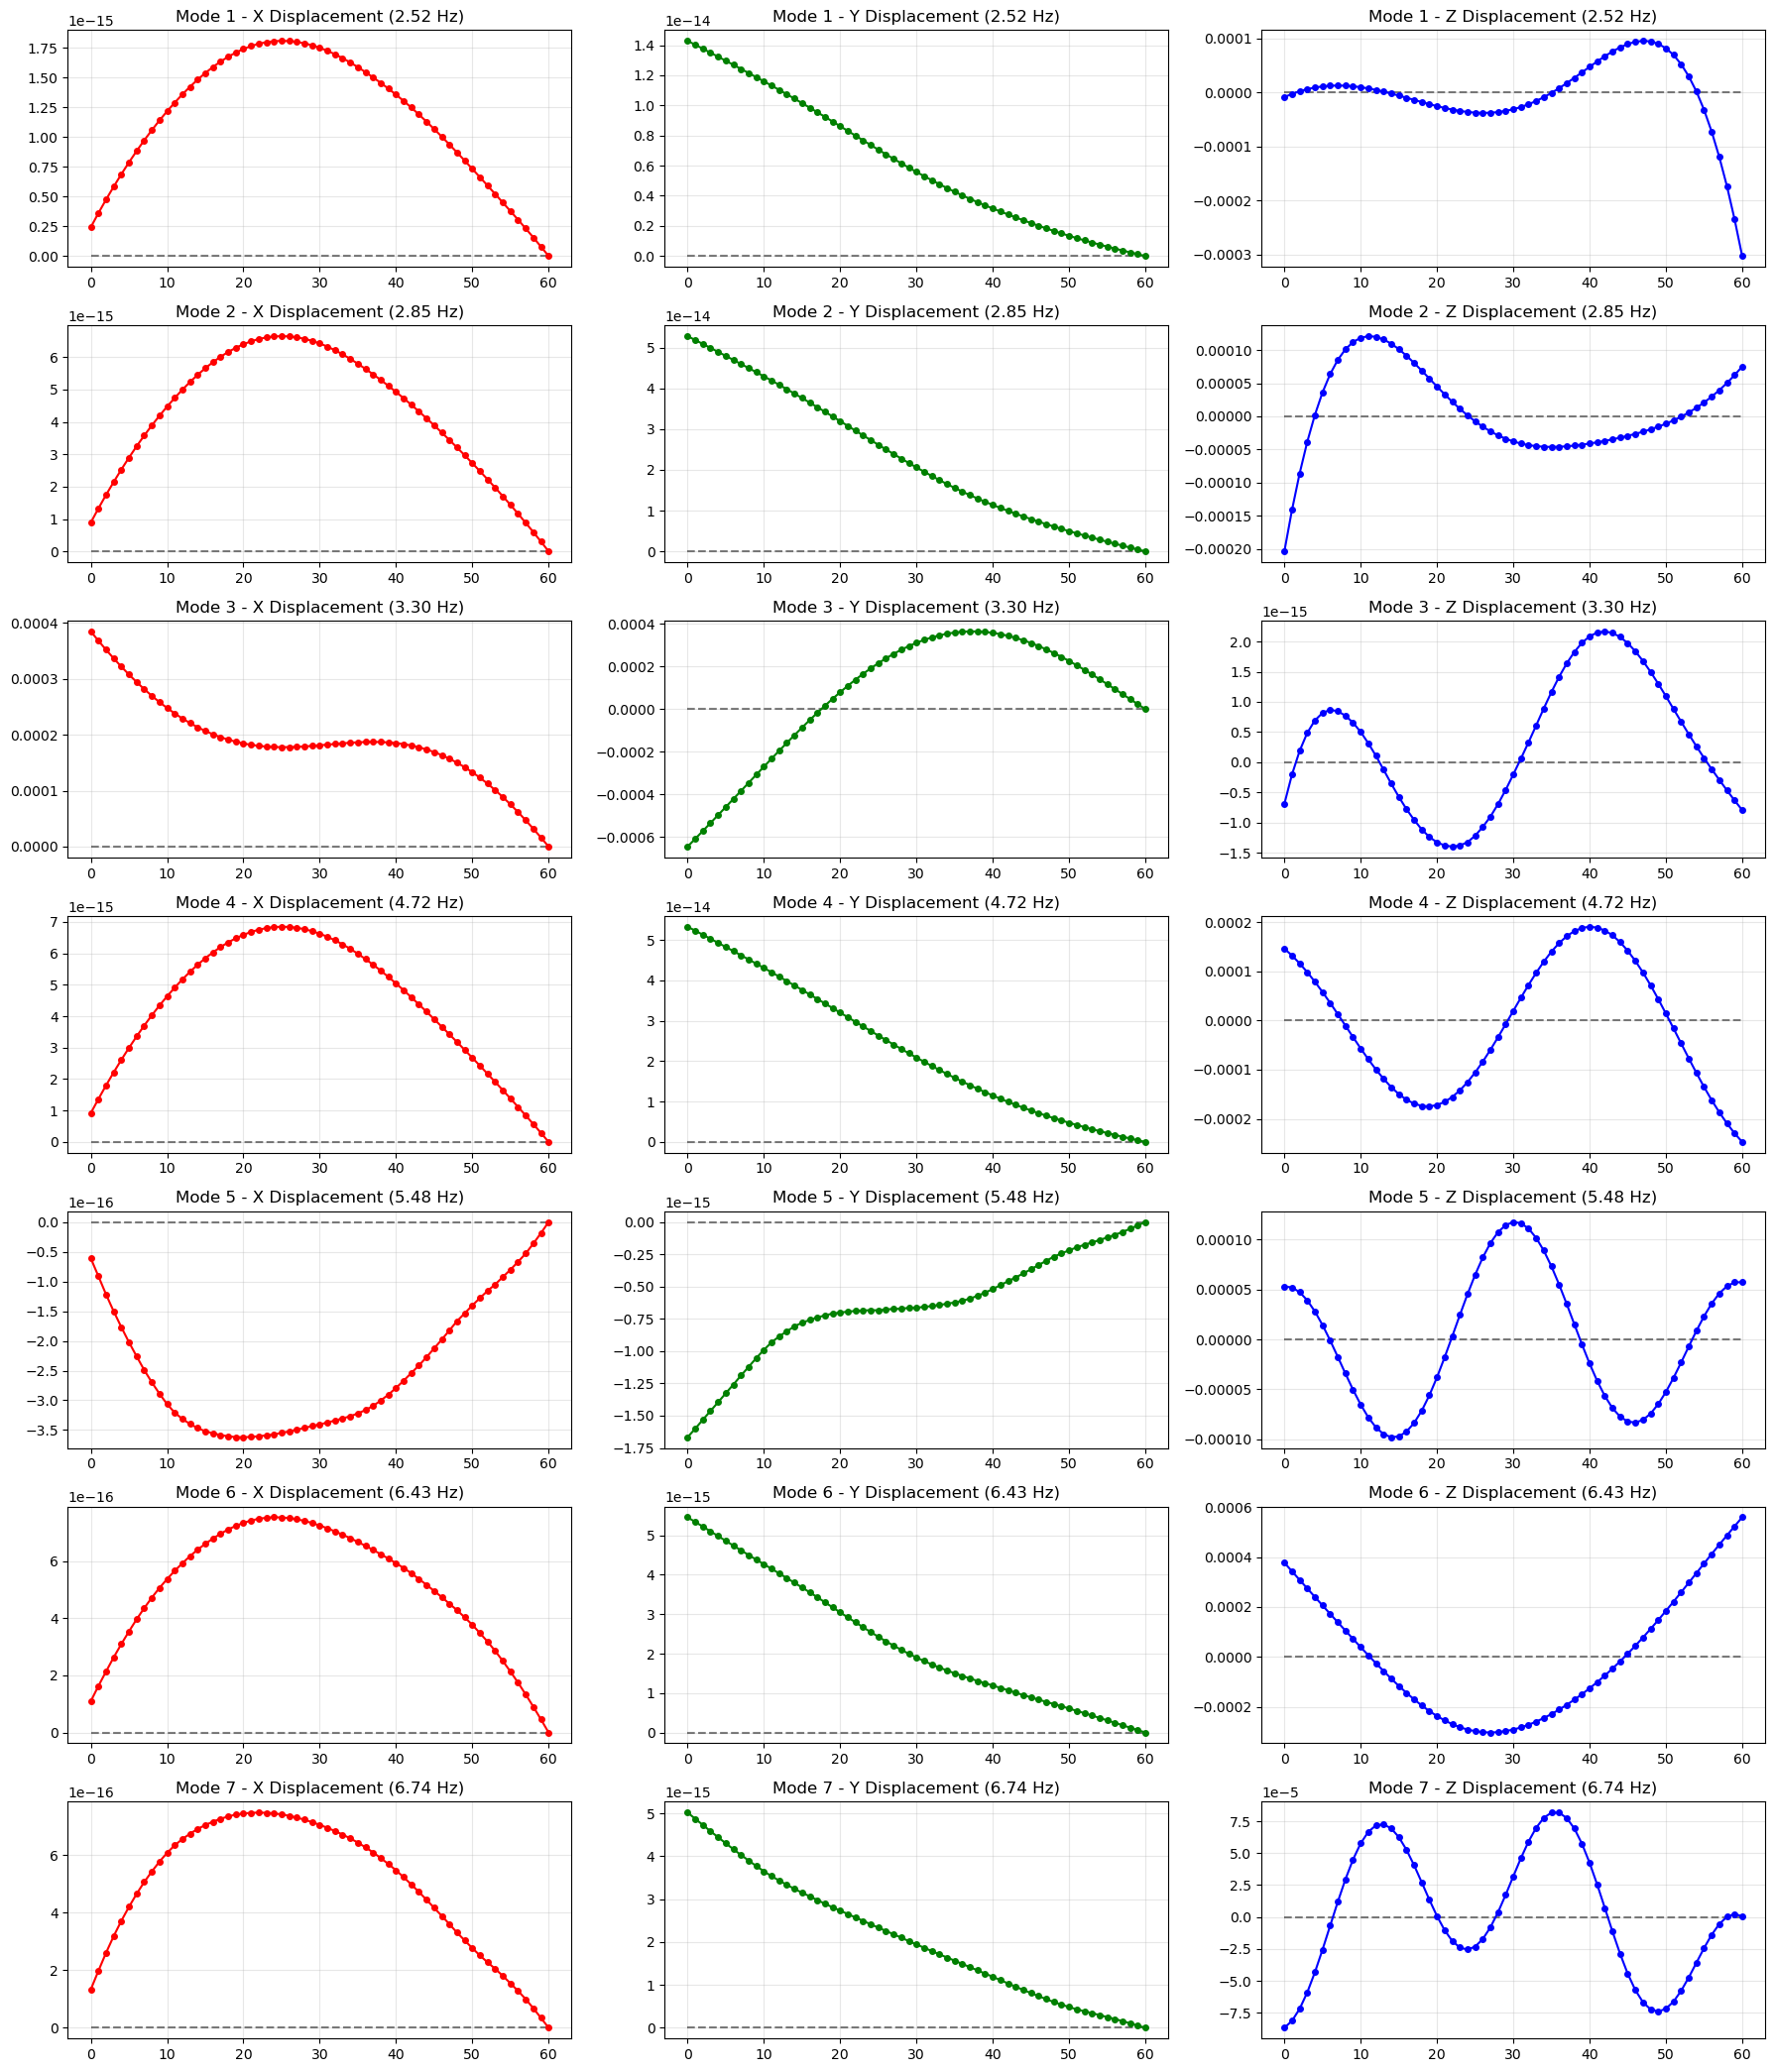

In [18]:
fig, axes = plt.subplots(modes_to_plot, 3, figsize=(18, 3*modes_to_plot))

if modes_to_plot == 1:
    axes = axes.reshape(1, 3)

x_undeformed = np.array([node[0] for node in nodes])
z_undeformed = np.array([node[2] for node in nodes])

for i in range(modes_to_plot):
    x_deformed = modes[i][:, 0]
    y_deformed = modes[i][:, 1]
    z_deformed = modes[i][:, 2]

    # shared y-limit for this row (mode)
    row_max = max(
        np.max(np.abs(x_deformed)),
        np.max(np.abs(y_deformed)),
        np.max(np.abs(z_deformed))
    )
    row_max = 1.1 * row_max if row_max > 0 else 1e-12

    # X
    ax_x = axes[i, 0]
    ax_x.plot(np.zeros_like(x_undeformed), 'k--', alpha=0.5)
    ax_x.plot(x_deformed, 'r-', marker='o', markersize=4)
    ax_x.set_title(f'Mode {i+1} - X Displacement ({frequencies_hz[i]:.2f} Hz)')
    # ax_x.set_ylim(-row_max, row_max)
    ax_x.grid(True, alpha=0.3)

    # Y
    ax_y = axes[i, 1]
    ax_y.plot(np.zeros_like(x_undeformed), 'k--', alpha=0.5)
    ax_y.plot(y_deformed, 'g-', marker='o', markersize=4)
    ax_y.set_title(f'Mode {i+1} - Y Displacement ({frequencies_hz[i]:.2f} Hz)')
    # ax_y.set_ylim(-row_max, row_max)
    ax_y.grid(True, alpha=0.3)

    # Z
    ax_z = axes[i, 2]
    ax_z.plot(z_undeformed, 'k--', alpha=0.5)
    ax_z.plot(z_deformed, 'b-', marker='o', markersize=4)
    ax_z.set_title(f'Mode {i+1} - Z Displacement ({frequencies_hz[i]:.2f} Hz)')
    # ax_z.set_ylim(-row_max, row_max)
    ax_z.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

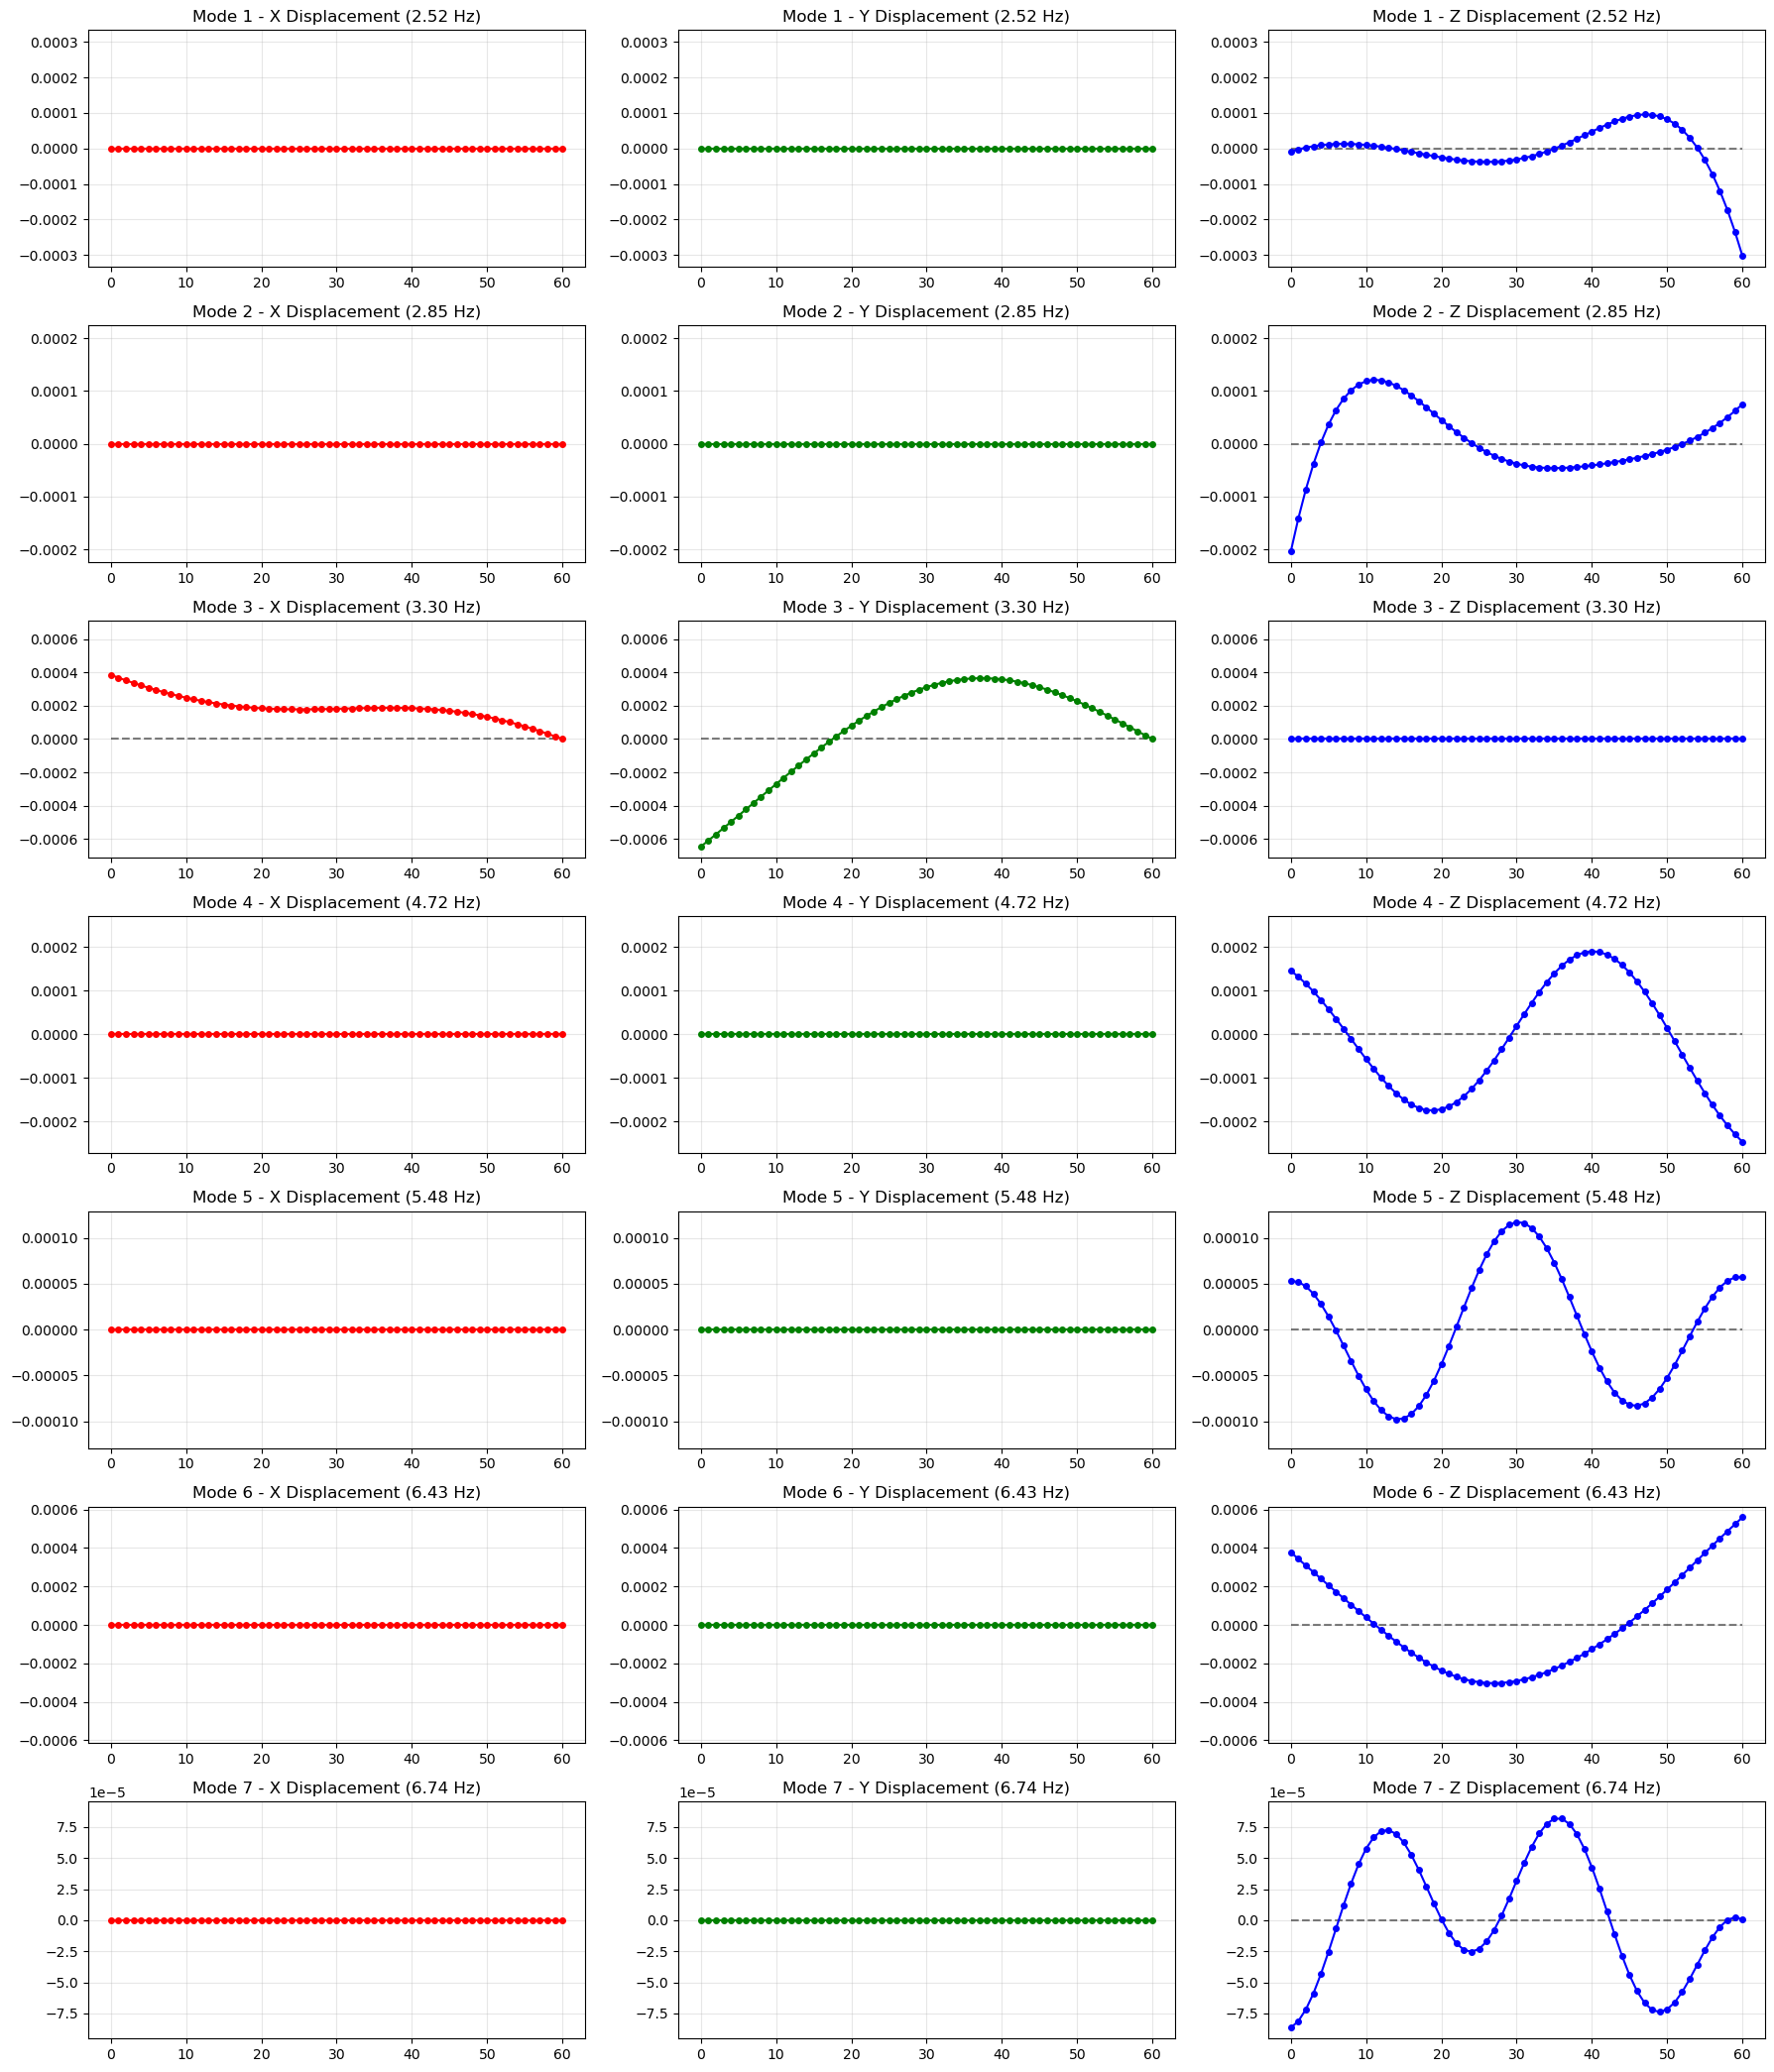

In [19]:
fig, axes = plt.subplots(modes_to_plot, 3, figsize=(18, 3 * modes_to_plot))

if modes_to_plot == 1:
    axes = axes.reshape(1, 3)

retaining_wall_nodes_arr = np.asarray(nodes)
x_undeformed = retaining_wall_nodes_arr[:, 0]
y_undeformed = retaining_wall_nodes_arr[:, 1]
z_undeformed = retaining_wall_nodes_arr[:, 2]

for i in range(modes_to_plot):
    x_deformed = modes[i][:, 0]
    y_deformed = modes[i][:, 1]
    z_deformed = modes[i][:, 2]

    row_max = max(
        np.max(np.abs(x_deformed)),
        np.max(np.abs(y_deformed)),
        np.max(np.abs(z_deformed))
    )
    row_max = 1.1 * row_max if row_max > 0 else 1e-12

    # X
    ax_x = axes[i, 0]
    ax_x.plot(np.zeros_like(x_undeformed), "k--", alpha=0.5)
    ax_x.plot(x_deformed, "r-", marker="o", markersize=4)
    ax_x.set_title(f"Mode {i+1} - X Displacement ({frequencies_hz[i]:.2f} Hz)")
    ax_x.set_ylim(-row_max, row_max)
    ax_x.grid(True, alpha=0.3)

    # Y
    ax_y = axes[i, 1]
    ax_y.plot(np.zeros_like(x_undeformed), "k--", alpha=0.5)
    ax_y.plot(y_deformed, "g-", marker="o", markersize=4)
    ax_y.set_title(f"Mode {i+1} - Y Displacement ({frequencies_hz[i]:.2f} Hz)")
    ax_y.set_ylim(-row_max, row_max)
    ax_y.grid(True, alpha=0.3)

    # Z
    ax_z = axes[i, 2]
    ax_z.plot(z_undeformed, "k--", alpha=0.5)
    ax_z.plot(z_deformed, "b-", marker="o", markersize=4)
    ax_z.set_title(f"Mode {i+1} - Z Displacement ({frequencies_hz[i]:.2f} Hz)")
    ax_z.set_ylim(-row_max, row_max)
    ax_z.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()